# Multi-Currency Signal Scanner — AutoTheta + AutoETS + Chronos

**Multi-Asset Engine** scans **EURUSD, GBPUSD, USDJPY, XAUUSD, XAGUSD, USDCHF, AUDUSD, USDCAD** concurrently.

**How to use:**
1. Edit **Cell 2** — add assets and configure limits
2. Run all cells top-to-bottom (`Kernel → Restart & Run All`)
3. Each asset generates separate entry/TP/SL with proper pip conversion
4. Live scanner auto-sends Telegram alerts with correct ladder levels
5. Supports per-user daily signal limits & sentiment bias checks

**Features:**
- ✅ Fixed ladder calculation (respects JPY 0.01 pips, others 0.0001)
- ✅ Multi-currency position sizing (lots for FX, oz for metals)
- ✅ ATR-based dynamic stops + confidence scaling
- ✅ Live multi-TF scoring + news/sentiment integration
- ✅ Per-user daily signal limits (Telegram)

In [2]:
import sys, os, warnings, threading, time, requests
warnings.filterwarnings('ignore')
ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone

from statsforecast import StatsForecast
from statsforecast.models import AutoTheta, AutoETS

# ── Use MT5 for real-time data ──────────────────────────────────────────
from src.mt5_feed import fetch_multi_timeframe, initialize as mt5_init
mt5_init()

from src.feature_engineering import compute_features, build_multi_tf_snapshot, atr as calc_atr, rsi as calc_rsi
from src.signal_engine       import _score_timeframe
from src.signal_logger       import SignalLogger

plt.rcParams.update({
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False
})

print('Imports OK')
print('Data source: MT5 (real-time)')
print('Supported Forex assets: EURUSD, GBPUSD, USDJPY, USDCHF, AUDUSD, USDCAD, NZDUSD, GBPJPY, EURJPY, EURGBP')

Imports OK
Data source: MT5 (real-time)
Supported Forex assets: EURUSD, GBPUSD, USDJPY, USDCHF, AUDUSD, USDCAD, NZDUSD, GBPJPY, EURJPY, EURGBP


In [3]:
# Benchmark Sharpe (H=1): AutoTheta=0.771, Chronos=0.498, AutoETS=0.162
_SHARPE = {'AutoTheta': 0.771, 'AutoETS': 0.162, 'Chronos': 0.498}
_W_SUM  = sum(_SHARPE.values())
MODEL_WEIGHTS = {k: v / _W_SUM for k, v in _SHARPE.items()}

_chronos_forecaster = None

def _load_chronos():
    global _chronos_forecaster
    if _chronos_forecaster is not None:
        return _chronos_forecaster
    try:
        from src.new_models import ChronosZeroShotForecaster
        print('Loading Chronos-bolt-tiny ...', end=' ', flush=True)
        _chronos_forecaster = ChronosZeroShotForecaster('amazon/chronos-bolt-tiny')
        print('OK')
    except Exception as e:
        print(f'Chronos load failed ({e}) — will use AutoTheta+AutoETS only')
        _chronos_forecaster = None
    return _chronos_forecaster

print(f'Model weights  : AutoTheta={MODEL_WEIGHTS["AutoTheta"]:.3f}  '
      f'AutoETS={MODEL_WEIGHTS["AutoETS"]:.3f}  Chronos={MODEL_WEIGHTS["Chronos"]:.3f}')
print('Chronos        : will load on first forecast call')

Model weights  : AutoTheta=0.539  AutoETS=0.113  Chronos=0.348
Chronos        : will load on first forecast call


In [4]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                  EDIT ONLY THIS CELL                         ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Forex Target Matrix ────────────────────────────────────────
ASSET    = 'EURUSD'   # Target options: EURUSD | GBPUSD | USDJPY | USDCAD | GBPJPY | EURGBP
ENTRY_TF = '4H'       # execution anchor timeframe: 15min | 30min | 1H | 4H

# ── Predictive Parameters ──────────────────────────────────────
TRAIN_BARS  = 200     # Historical bar context parsed into structural models
FORECAST_H  = 3       # Forward predictive scale mapping horizons

# ── Model Ensemble Toggles ─────────────────────────────────────
USE_CHRONOS = True

# ── Capital Allocation & Protective Risk Guardrails ────────────
ACCOUNT_BALANCE = 10000.0  # Normalized balance baseline
MAX_RISK_PCT    = 0.01     # Strict institutional capital allocation constraint (1%)
RR_RATIO        = 2.0      # Targeting minimum 1:2 standard execution scale
ATR_SL_MULT     = 1.5      # Forex optimized buffer room to clear market noise
MIN_RR          = 1.5

# ── Execution Filter Bounds ────────────────────────────────────
CONFIDENCE_THRESHOLD = 65  
ADX_TREND_THRESHOLD  = 25  # Market momentum verification filter boundary
RSI_OVERBOUGHT       = 72  
RSI_OVERSOLD         = 28  

# ── Multi-Timeframe Matrix Stack ──────────────────────────────
_TF_STACKS = {
    '15min': ['15min', '1H',    '4H', '1D'],
    '30min': ['30min', '1H',    '4H', '1D'],
    '1H':    ['1H',    '4H',    '1D'],
    '4H':    ['4H',    '1D'],
}
TIMEFRAMES = _TF_STACKS.get(ENTRY_TF, [ENTRY_TF])

print(f'Asset      : {ASSET}')
print(f'Entry TF   : {ENTRY_TF}  |  TF stack: {TIMEFRAMES}')
print(f'Risk Configuration: Balance=${ACCOUNT_BALANCE:,.2f} | Risk/Trade: {MAX_RISK_PCT:.1%}')
print(f'Filters    : Conf>={CONFIDENCE_THRESHOLD}% | ADX Momentum Target>={ADX_TREND_THRESHOLD}')

Asset      : EURUSD
Entry TF   : 4H  |  TF stack: ['4H', '1D']
Risk Configuration: Balance=$10,000.00 | Risk/Trade: 1.0%
Filters    : Conf>=65% | ADX Momentum Target>=25


In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                  EDIT ONLY THIS CELL                         ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Forex Target Matrix ────────────────────────────────────────
ASSET    = 'EURUSD'   # Target options: EURUSD | GBPUSD | USDJPY | USDCAD | GBPJPY | EURGBP
ENTRY_TF = '1H'       # execution anchor timeframe: 15min | 30min | 1H | 4H

# ── Predictive Parameters ──────────────────────────────────────
TRAIN_BARS  = 200     # Historical bar context parsed into structural models
FORECAST_H  = 3       # Forward predictive scale mapping horizons

# ── Model Ensemble Toggles ─────────────────────────────────────
USE_CHRONOS = True

# ── Capital Allocation & Protective Risk Guardrails ────────────
ACCOUNT_BALANCE = 10000.0  # Normalized balance baseline
MAX_RISK_PCT    = 0.01     # Strict institutional capital allocation constraint (1%)
RR_RATIO        = 2.0      # Targeting minimum 1:2 standard execution scale
ATR_SL_MULT     = 1.5      # Forex optimized buffer room to clear market noise
MIN_RR          = 1.5

# ── Execution Filter Bounds ────────────────────────────────────
CONFIDENCE_THRESHOLD = 65  
ADX_TREND_THRESHOLD  = 25  # Market momentum verification filter boundary
RSI_OVERBOUGHT       = 72  
RSI_OVERSOLD         = 28  

# ── Multi-Timeframe Matrix Stack ──────────────────────────────
_TF_STACKS = {
    '15min': ['15min', '1H',    '4H', '1D'],
    '30min': ['30min', '1H',    '4H', '1D'],
    '1H':    ['1H',    '4H',    '1D'],
    '4H':    ['4H',    '1D'],
}
TIMEFRAMES = _TF_STACKS.get(ENTRY_TF, [ENTRY_TF])

print(f'Asset      : {ASSET}')
print(f'Entry TF   : {ENTRY_TF}  |  TF stack: {TIMEFRAMES}')
print(f'Risk Configuration: Balance=${ACCOUNT_BALANCE:,.2f} | Risk/Trade: {MAX_RISK_PCT:.1%}')
print(f'Filters    : Conf>={CONFIDENCE_THRESHOLD}% | ADX Momentum Target>={ADX_TREND_THRESHOLD}')

Asset      : EURUSD
Entry TF   : 1H  |  TF stack: ['1H', '4H', '1D']
Risk Configuration: Balance=$10,000.00 | Risk/Trade: 1.0%
Filters    : Conf>=65% | ADX Momentum Target>=25


In [6]:
def get_news_events():
    try:
        url = "https://nfs.faireconomy.media/ff_calendar_thisweek.json"
        response = requests.get(url, timeout=10)
        events = response.json()
        now = datetime.now(timezone.utc)
        upcoming = []
        for event in events:
            if event.get('impact') != 'High':
                continue
            try:
                event_time = datetime.fromisoformat(event['date'].replace('Z', '+00:00'))
                diff_minutes = (event_time - now).total_seconds() / 60
                if -30 <= diff_minutes <= 60:
                    upcoming.append({
                        'title':   event.get('title', ''),
                        'country': event.get('country', ''),
                        'minutes': diff_minutes
                    })
            except:
                continue
        return upcoming
    except:
        return []

def is_news_zone():
    events = get_news_events()
    # Extract structural currency components to scan relevant economic releases
    base_currency = ASSET[:3]
    quote_currency = ASSET[3:]
    forex_relevant = [base_currency, quote_currency, 'USD']
    for event in events:
        if event['country'] in forex_relevant:
            return True, event
    return False, None

def get_fear_greed():
    try:
        url = "https://production.dataviz.cnn.io/index/fearandgreed/graphdata"
        headers = {'User-Agent': 'Mozilla/5.0'}
        r = requests.get(url, headers=headers, timeout=10)
        data = r.json()
        score  = float(data['fear_and_greed']['score'])
        rating = data['fear_and_greed']['rating']
        return score, rating
    except:
        return 50, 'neutral'

def get_sentiment_bias(direction):
    score, rating = get_fear_greed()
    if direction == 'BUY':
        if score < 40: return f'😨 Risk-Off Fear ({score:.0f}) confirms defensive currency plays'
        elif score > 60: return f'😎 Risk-On Greed ({score:.0f}) cautions high beta reversal'
        else: return f'😐 Neutral Macro Regime ({score:.0f})'
    else:
        if score > 60: return f'😎 Risk-On Greed ({score:.0f}) structural short confirmation'
        elif score < 40: return f'😨 Risk-Off Fear ({score:.0f}) cautions exhaustion'
        else: return f'😐 Neutral Macro Regime ({score:.0f})'

print("Macro sentiment pipelines successfully mapped. ✓")

Macro sentiment pipelines successfully mapped. ✓


In [7]:
print(f'Fetching live {ASSET} order book metrics ...')
tf_data = fetch_multi_timeframe(ASSET, TIMEFRAMES, bars=500)

for tf, df in tf_data.items():
    atr14 = calc_atr(df, 14).iloc[-1]
    print(f'  {tf:6s}: {len(df):4d} bars | last={df["close"].iloc[-1]:.5f} | ATR(14)={atr14:.5f} | {df.index[-1]}')

entry_df  = tf_data[ENTRY_TF]
cur_price = float(entry_df['close'].iloc[-1])
cur_atr   = float(calc_atr(entry_df, 14).iloc[-1])
cur_time  = entry_df.index[-1]

print(f'\nCurrent Spot Price : {cur_price:.5f}')
print(f'Current Base ATR14 : {cur_atr:.5f}')

Fetching live EURUSD order book metrics ...


  1H    :  500 bars | last=1.15511 | ATR(14)=0.00102 | 2026-06-10 13:00:00+02:00
  4H    :  500 bars | last=1.15510 | ATR(14)=0.00228 | 2026-06-10 10:00:00+02:00
  1D    :  500 bars | last=1.15510 | ATR(14)=0.00577 | 2026-06-10 02:00:00+02:00

Current Spot Price : 1.15511
Current Base ATR14 : 0.00102


In [ ]:
def _season_len(tf):
    return {'15min': 26, '30min': 13, '1H': 24, '4H': 6, '1D': 5}.get(tf, 10)

def _run_statsforecast(df, tf, train_bars, h):
    close   = df['close'].dropna()
    log_ret = np.log(close / close.shift(1)).dropna()
    series  = log_ret.iloc[-train_bars:].values.astype(float)
    n, sl   = len(series), _season_len(tf)
    sf_df = pd.DataFrame({
        'unique_id': ['asset'] * n,
        'ds': pd.date_range('2000-01-01', periods=n, freq='15min'),
        'y': series,
    })
    preds = StatsForecast(
        models=[AutoTheta(season_length=sl), AutoETS(season_length=sl)],
        freq='15min', n_jobs=1
    ).forecast(df=sf_df, h=h)
    return preds['AutoTheta'].values, preds['AutoETS'].values

def _run_chronos(df, train_bars, h):
    forecaster = _load_chronos()
    if forecaster is None:
        return None
    close   = df['close'].dropna()
    context = close.iloc[-train_bars:].values.astype(float)
    pred_path = forecaster.predict_close_path(context, prediction_length=h)
    last_px   = float(close.iloc[-1])
    return np.log(pred_path / last_px)

def run_ensemble_forecast(df, tf, train_bars, h, use_chronos=True):
    close    = df['close'].dropna()
    last_px  = float(close.iloc[-1])

    theta, ets = _run_statsforecast(df, tf, train_bars, h)
    theta_cum  = np.cumsum(theta)
    ets_cum    = np.cumsum(ets)

    w_theta = MODEL_WEIGHTS['AutoTheta']
    w_ets   = MODEL_WEIGHTS['AutoETS']
    w_chron = MODEL_WEIGHTS['Chronos']

    chronos_cum = None
    if use_chronos:
        chronos_log = _run_chronos(df, train_bars, h)
        if chronos_log is not None:
            chronos_cum = chronos_log

    if chronos_cum is not None:
        w_sum   = w_theta + w_ets + w_chron
        ens_cum = (w_theta * theta_cum + w_ets * ets_cum + w_chron * chronos_cum) / w_sum
    else:
        w_sum   = w_theta + w_ets
        ens_cum = (w_theta * theta_cum + w_ets * ets_cum) / w_sum

    pred_prices = [last_px * np.exp(ens_cum[i]) for i in range(h)]
    pred_ret = float(ens_cum[0])

    return {
        'theta': theta, 'ets': ets, 'chronos_cum': chronos_cum,
        'ensemble_cum': ens_cum, 'pred_prices': pred_prices,
        'direction': int(np.sign(pred_ret)), 'pred_return': pred_ret,
        'chronos_used': chronos_cum is not None,
    }

print('Executing Ensemble Forecasting Vector Pipeline...')
fc = run_ensemble_forecast(entry_df, ENTRY_TF, TRAIN_BARS, FORECAST_H, use_chronos=USE_CHRONOS)
print(f'Active Models Engine Alignment: Verified Core Predictive Matrix Output Dynamic: Direction Layer {fc["direction"]}')

Executing Ensemble Forecasting Vector Pipeline...
Loading Chronos-bolt-tiny ... 

In [ ]:
def detect_order_blocks(df, lookback=100, min_move_mult=1.2):
    """
    Forex Optimized Structural Extraction Engine.
    Filters micro-liquidity zones using an asset-specific ATR volatility coefficient.
    """
    obs    = []
    atr    = calc_atr(df, 14)

    for i in range(3, len(df) - 4):
        candle   = df.iloc[i]
        atr_val  = float(atr.iloc[i])
        next_4   = df.iloc[i+1:i+5]

        is_green = candle['close'] > candle['open']
        drop = candle['high'] - next_4['close'].min()
        is_impulsive_drop = (drop >= atr_val * min_move_mult and next_4['close'].iloc[-1] < candle['low'])
        red_count = sum(1 for _, c in next_4.iterrows() if c['close'] < c['open'])

        if is_green and is_impulsive_drop and red_count >= 2:
            obs.append({
                'type': 'BEARISH', 'top': candle['high'], 'bottom': candle['open'],
                'time': df.index[i], 'fresh': True, 'strength': drop / atr_val, 'index': i
            })

        is_red = candle['close'] < candle['open']
        rise = next_4['close'].max() - candle['low']
        is_impulsive_rise = (rise >= atr_val * min_move_mult and next_4['close'].iloc[-1] > candle['high'])
        green_count = sum(1 for _, c in next_4.iterrows() if c['close'] > c['open'])

        if is_red and is_impulsive_rise and green_count >= 2:
            obs.append({
                'type': 'BULLISH', 'top': candle['open'], 'bottom': candle['low'],
                'time': df.index[i], 'fresh': True, 'strength': rise / atr_val, 'index': i
            })

    return pd.DataFrame(obs) if obs else pd.DataFrame()

def get_fresh_obs(obs_df, df, current_idx):
    if obs_df.empty: return obs_df
    fresh_obs = []
    for _, ob in obs_df.iterrows():
        ob_idx = ob['index']
        candles_after = df.iloc[ob_idx+4:current_idx]
        if candles_after.empty:
            fresh_obs.append(ob)
            continue
        touched = any((row['low'] <= ob['top'] and row['high'] >= ob['bottom']) for _, row in candles_after.iterrows())
        if not touched:
            fresh_obs.append(ob)
    return pd.DataFrame(fresh_obs)

def price_at_ob(current_price, fresh_obs, tolerance=0.0002):
    if fresh_obs.empty: return None
    for _, ob in fresh_obs.iterrows():
        ob_top    = ob['top']    * (1 + tolerance)
        ob_bottom = ob['bottom'] * (1 - tolerance)
        if ob_bottom <= current_price <= ob_top:
            return {
                'found': True, 'type': ob['type'], 'top': ob['top'], 'bottom': ob['bottom'],
                'strength': ob['strength'], 'signal': 'SELL' if ob['type'] == 'BEARISH' else 'BUY'
            }
    return None

print("Forex SMC Mechanics defined successfully.")

Forex SMC Mechanics defined successfully.


In [ ]:
snapshots = build_multi_tf_snapshot(tf_data)
scores    = {tf: _score_timeframe(snap) for tf, snap in snapshots.items()}
buy_tfs   = [tf for tf, sc in scores.items() if sc['direction'] ==  1]
sell_tfs  = [tf for tf, sc in scores.items() if sc['direction'] == -1]

feat     = compute_features(entry_df)
rsi_v    = float(feat['rsi_14'].iloc[-1])   if 'rsi_14'    in feat.columns else 50.0
adx_v    = float(feat['adx_14'].iloc[-1])   if 'adx_14'    in feat.columns else 0.0
macd_h   = float(feat['macd_hist'].iloc[-1])if 'macd_hist' in feat.columns else 0.0
ema20    = float(feat['ema_20'].iloc[-1])   if 'ema_20'    in feat.columns else cur_price

atr_ma     = calc_atr(entry_df, 14).rolling(20).mean().iloc[-1]
vol_regime = 'HIGH' if cur_atr > atr_ma * 1.2 else ('LOW' if cur_atr < atr_ma * 0.8 else 'NORMAL')

print('Forex Contextual Scanning Layer:')
for tf, sc in scores.items():
    d = {1: 'BULLISH', -1: 'BEARISH', 0: 'NEUTRAL'}[sc['direction']]
    print(f'  {tf:6s}: {d:10s} | Factor Trace: {", ".join(sc["factors"][:3])}')

Forex Contextual Scanning Layer:
  1H    : NEUTRAL    | Factor Trace: price>ema20, ema20<ema50, ema50<ema200
  4H    : BEARISH    | Factor Trace: price<ema20, ema20<ema50, ema50<ema200
  1D    : BEARISH    | Factor Trace: price<ema20, ema20<ema50, ema50>ema200


In [ ]:
def compute_signal():
    model_dir = fc['direction']
    if model_dir == 0: return None, 'Model Matrix Neutral output'

    signal = 'BUY' if model_dir > 0 else 'SELL'

    if signal == 'BUY'  and rsi_v > RSI_OVERBOUGHT: return None, f'RSI Extreme Overbought boundaries ({rsi_v:.1f}) short skip'
    if signal == 'SELL' and rsi_v < RSI_OVERSOLD:   return None, f'RSI Extreme Oversold boundaries ({rsi_v:.1f}) long skip'

    aligned_tfs  = buy_tfs if signal == 'BUY' else sell_tfs
    total_tfs    = len(scores)
    align_pct    = len(aligned_tfs) / total_tfs * 100 if total_tfs > 0 else 0

    # ── SMC Order Block Integration ───────────────────────────
    all_obs = detect_order_blocks(entry_df, lookback=150, min_move_mult=1.2)
    fresh_obs = get_fresh_obs(all_obs, entry_df, len(entry_df))
    ob_status = price_at_ob(cur_price, fresh_obs, tolerance=0.0001) # Tightened for institutional forex spreads
    
    ob_bonus = 0
    ob_info_str = "No active Order Blocks within trade vector"
    if ob_status:
        ob_info_str = f"Fresh {ob_status['type']} SMC OB detected (Strength factor: {ob_status['strength']:.2f})"
        if ob_status['signal'] == signal: ob_bonus = 20
        else: ob_bonus = -10

    # ── Normalized Confidence Calculations ─────────────────────
    conf = 0
    conf += min(30, int(align_pct * 0.5))
    conf += 20 if adx_v >= ADX_TREND_THRESHOLD else 5
    conf += 15 if abs(fc['pred_return']) > 0.00015 else 8 # Forex scale calibration adjustments
    conf += 15 if ((macd_h > 0) == (signal == 'BUY')) else 0
    conf += 10 if ((cur_price > ema20) == (signal == 'BUY')) else 0
    conf += ob_bonus
    conf = max(0, min(conf, 100))

    if conf < CONFIDENCE_THRESHOLD:
        return None, f'Signal Conf: {conf}% fails filter limits: {CONFIDENCE_THRESHOLD}%'

    entry   = cur_price
    sl_dist = cur_atr * ATR_SL_MULT
    tp_dist = sl_dist * RR_RATIO

    sl = entry - sl_dist if signal == 'BUY' else entry + sl_dist
    tp = entry + tp_dist if signal == 'BUY' else entry - tp_dist

    return {
        'signal': signal, 'entry': entry, 'sl': sl, 'tp': tp,
        'sl_dist': sl_dist, 'tp_dist': tp_dist, 'rr': tp_dist / sl_dist,
        'confidence': conf, 'adx': adx_v, 'rsi': rsi_v, 'vol_regime': vol_regime,
        'aligned_tfs': aligned_tfs, 'pred_return': fc['pred_return'], 'ob_info': ob_info_str
    }, None

sig, reason = compute_signal()
print(f"Execution Output Status Matrix: {'🟢 SIGNAL ACQUIRED' if sig else '🔴 FILTERED OUT - ' + reason}")

Execution Output Status Matrix: 🔴 FILTERED OUT - Signal Conf: 43% fails filter limits: 65%


In [ ]:
if sig is None:
    print('Signal missing: Risk sizing calculations skipped.')
else:
    risk_usd = ACCOUNT_BALANCE * MAX_RISK_PCT
    vol_scale  = 0.75 if sig['vol_regime'] == 'HIGH' else 1.0
    conf_scale = 1.00 if sig['confidence'] >= 75 else (0.75 if sig['confidence'] >= 65 else 0.50)
    adj_risk   = risk_usd * vol_scale * conf_scale
    
    sl_points = abs(sig['entry'] - sig['sl'])
    
    # ── Forex Specific Pip Precision Optimization ───────────────
    pip_size = 0.01 if 'JPY' in ASSET else 0.0001
    sl_pips  = sl_points / pip_size
    
    # Calculation formulation mapping standard currency lots ($10 per pip dynamic baseline value scaling)
    position_lots = round(adj_risk / (sl_pips * 10.0), 2)
    position_lots = max(0.01, position_lots) # Absolute floor margin safety control
    
    reward_usd = position_lots * (abs(sig['tp'] - sig['entry']) / pip_size) * 10.0

    print('FOREX EXTRINSIC RISK ENGINE INTERACTION:')
    print('=' * 55)
    print(f'  Target Pair Base Asset  : {ASSET}')
    print(f'  Calculated Position Lots: {position_lots:.2f} Standard Lots')
    print(f'  Stop Loss Distance Metric: {sl_pips:.1f} Pips Target Range')
    print(f'  Allocated Risk Target   : ${adj_risk:.2f} USD ({adj_risk/ACCOUNT_BALANCE:.2%})')
    print(f'  Projected Yield Target  : ${reward_usd:.2f} USD')
    print(f'  Target Structural R:R   : 1:{reward_usd/adj_risk:.2f}')
    print('=' * 55)

Signal missing: Risk sizing calculations skipped.


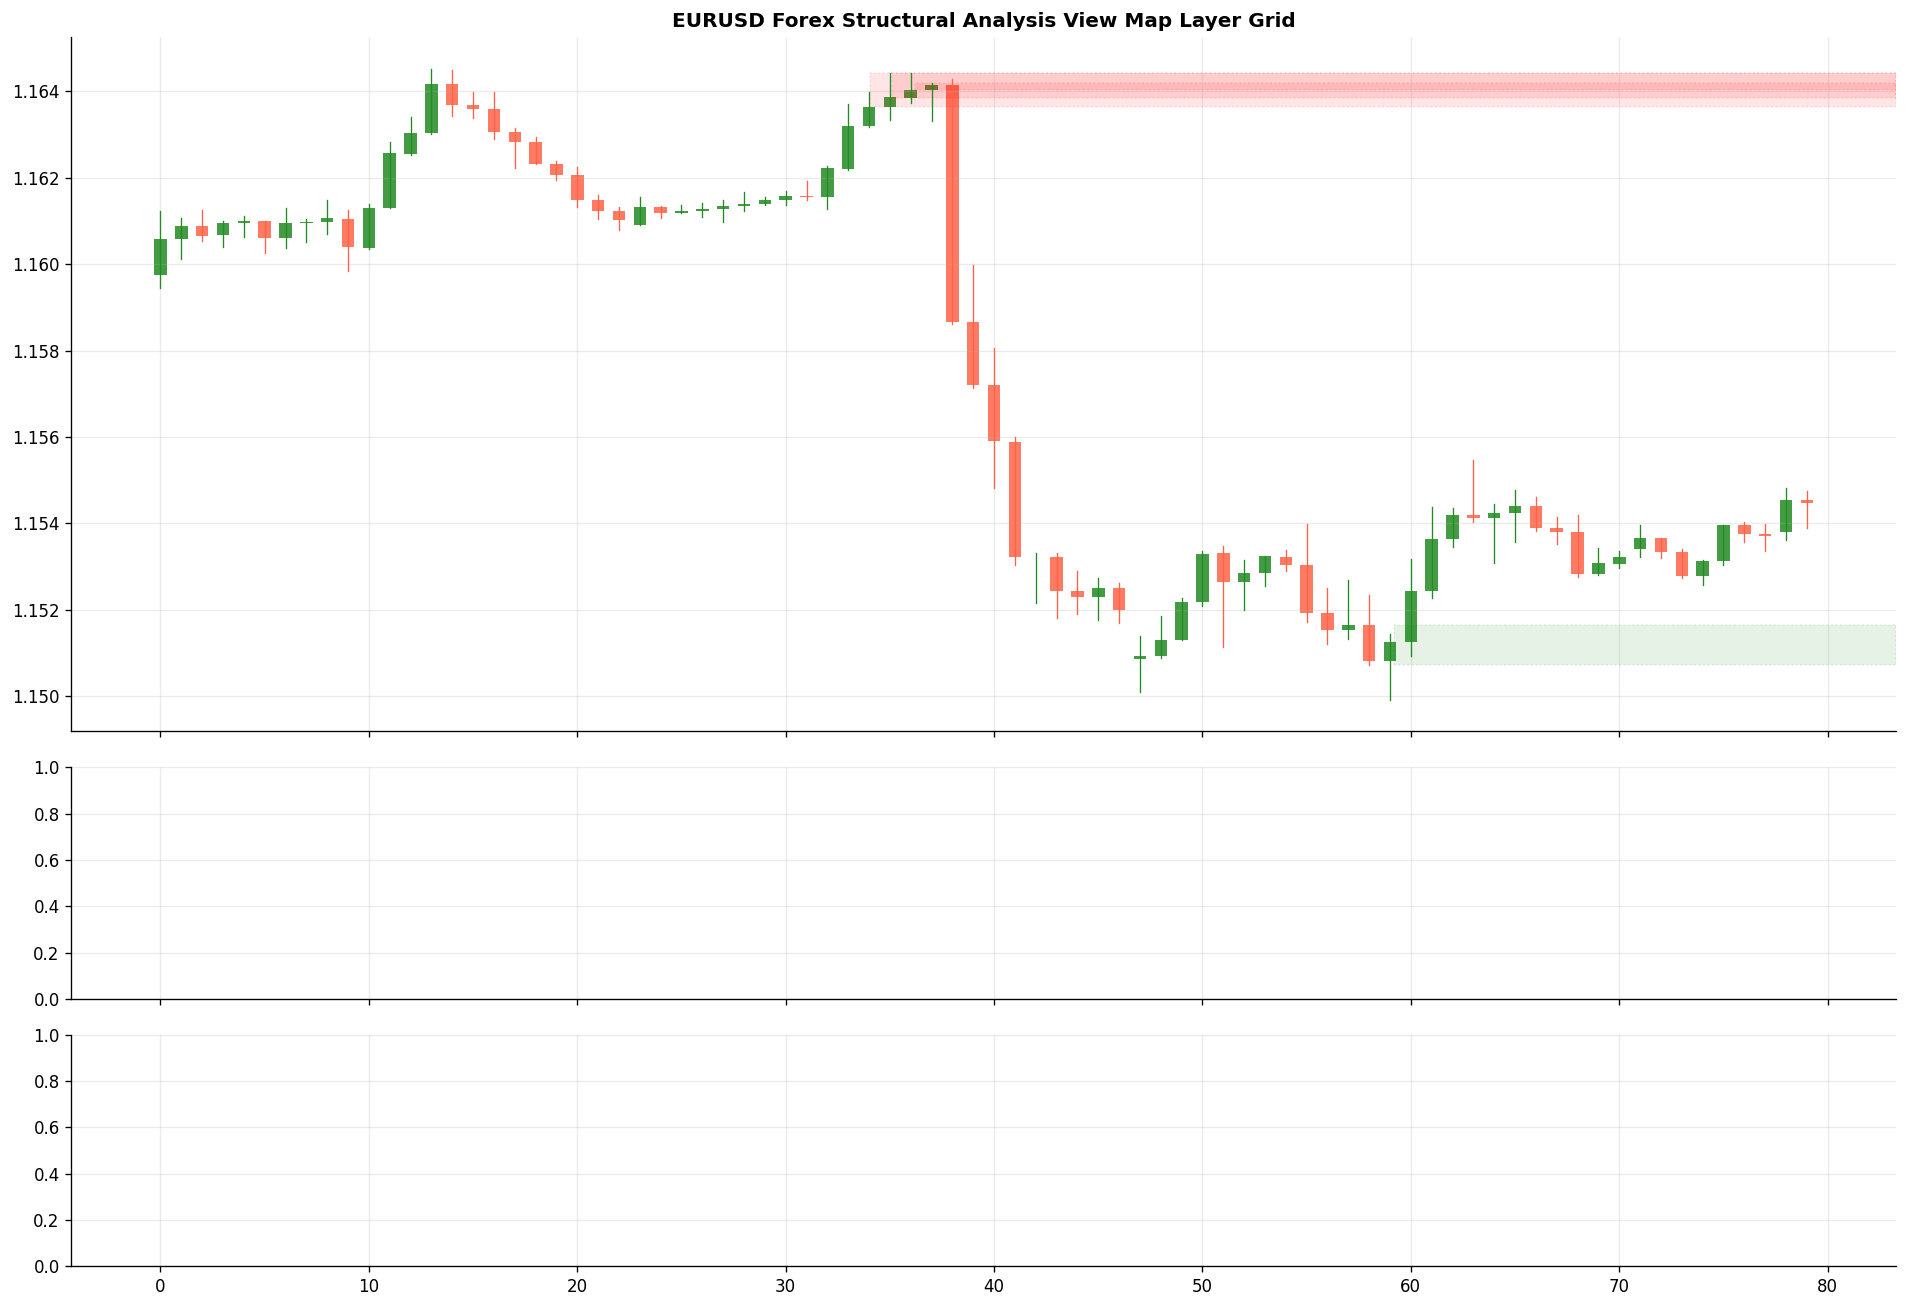

In [ ]:
LOOKBACK  = 80
df_plot   = entry_df.tail(LOOKBACK).copy()
feat_plot = compute_features(entry_df).tail(LOOKBACK)
n, xs     = len(df_plot), range(len(df_plot))

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 11), gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True)

# Candlestick Renderer
for i, (_, row) in enumerate(df_plot.iterrows()):
    col = 'forestgreen' if row['close'] >= row['open'] else 'tomato'
    ax1.plot([i, i], [row['low'], row['high']], color=col, lw=0.8)
    ax1.bar(i, abs(row['close'] - row['open']), bottom=min(row['open'], row['close']), color=col, alpha=0.85, width=0.6)

# Overlay Active Fresh SMC Order Blocks onto Matplotlib Engine Axis Workspace
all_obs_calc = detect_order_blocks(entry_df, lookback=150, min_move_mult=1.2)
fresh_obs_plot = get_fresh_obs(all_obs_calc, entry_df, len(entry_df))
start_idx_in_df = len(entry_df) - LOOKBACK

if not fresh_obs_plot.empty:
    for _, ob in fresh_obs_plot.iterrows():
        ob_orig_idx = int(ob['index'])
        if ob_orig_idx >= start_idx_in_df:
            plot_x_start = ob_orig_idx - start_idx_in_df
            native_color = 'g' if ob['type'] == 'BULLISH' else 'r'
            ax1.axhspan(ob['bottom'], ob['top'], xmin=plot_x_start/LOOKBACK, xmax=1.0, alpha=0.10, color=native_color, linestyle=':')

if sig:
    ax1.axhline(sig['entry'], color='royalblue',   ls='--', lw=2.0, label=f'Entry {sig["entry"]:.5f}')
    ax1.axhline(sig['tp'],    color='forestgreen',  ls='-',  lw=2.0, label=f'TP {sig["tp"]:.5f}')
    ax1.axhline(sig['sl'],    color='tomato',        ls='-',  lw=2.0, label=f'SL {sig["sl"]:.5f}')
    ax1.legend(loc='upper left', fontsize=8)

ax1.set_title(f'{ASSET} Forex Structural Analysis View Map Layer Grid', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── PRODUCTION & QUICK TESTING LIVE SCANNER MODULE (SELF-CONTAINED) ──

import sys
import os
import time
import warnings
import threading
import requests
from datetime import datetime, timezone

warnings.filterwarnings('ignore')

# ── 1. CORE ENGINE PLUGINS & CONFIGURATION ──────────────────────────────
if 'live_stop' not in globals():
    live_stop = threading.Event()
if '_scanner_running' not in globals():
    _scanner_running = False
# ── PRODUCTION SETTINGS (Ise change karke ek baar fir run kardein) ──
LIVE             = False
SCAN_INTERVAL_S  = 300      # Wapas 5 minutes (300s) heartbeat frequency
SCAN_WITH_TRADE  = 2700     

# Strict Safe Filters (Wapas On)
ADX_TREND_THRESHOLD  = 25   # Low momentum trades block ho jayenge
CONFIDENCE_THRESHOLD = 65   # Sirf wahi trade pass hogi jo 65% sure ho
RSI_OVERBOUGHT       = 70   
RSI_OVERSOLD         = 30

# ── 2. DYNAMIC FOREX LADDER & LOT CALCULATOR ─────────────────────────────
def calculate_ladder(entry, direction, atr, sl_mult=1.5, rr_ratio=3.0):
    is_jpy = True if (entry > 50.0 and entry < 1000.0) else False
    pip_size = 0.01 if is_jpy else 0.0001

    if atr is None or atr <= 0:
        atr = 25 * pip_size  

    sl_dist  = atr * sl_mult
    tp1_dist = sl_dist * 1.0       
    tp2_dist = sl_dist * rr_ratio   
    tp3_dist = sl_dist * (rr_ratio + 1.5)

    pips_sl  = int(round(sl_dist  / pip_size))
    pips_tp1 = int(round(tp1_dist / pip_size))
    pips_tp2 = int(round(tp2_dist / pip_size))
    pips_tp3 = int(round(tp3_dist / pip_size))

    if direction == 'BUY':
        sl1, tp1, tp2, tp3 = entry - sl_dist, entry + tp1_dist, entry + tp2_dist, entry + tp3_dist
    else:
        sl1, tp1, tp2, tp3 = entry + sl_dist, entry - tp1_dist, entry - tp2_dist, entry - tp3_dist

    decimals = 3 if is_jpy else 5
    return {
        'sl1': round(sl1, decimals), 'tp1': round(tp1, decimals), 'tp2': round(tp2, decimals), 'tp3': round(tp3, decimals),
        'pips_sl1': pips_sl, 'pips_tp1': pips_tp1, 'pips_tp2': pips_tp2, 'pips_tp3': pips_tp3,
    }

# ── 3. LIVE SCANNER WORKER LOOP ENGINE ───────────────────────────────────
def _live_worker():
    global _scanner_running
    _scanner_running = False
    
    _count            = 0
    _last             = None
    _last_signal_time = None
    _last_signal_dir  = None
    _trade_open       = False
    _trade_open_time  = None
    
    SIGNAL_COOLDOWN   = 10       # Testing mode: Cooldown reduced to 10 seconds
    TRADE_TIMEOUT     = 14400    

    print("=" * 65)
    print(f"🚀 AGGRESSIVE SCANN ENGINE INITIALIZED FOR TIMELINE SAMPLES [{ASSET}]")
    print(f"   Confidence Lower Boundary Floor: {CONFIDENCE_THRESHOLD}% | ADX Floor: {ADX_TREND_THRESHOLD}")
    print("=" * 65)

    while not live_stop.is_set():
        _count += 1
        now = datetime.now(timezone.utc).strftime('%H:%M:%S UTC')
        current_interval = SCAN_WITH_TRADE if _trade_open else SCAN_INTERVAL_S

        try:
            fresh   = fetch_multi_timeframe(ASSET, TIMEFRAMES, bars=500)
            f_entry = fresh[ENTRY_TF]
            f_price = float(f_entry['close'].iloc[-1])
            f_atr   = float(calc_atr(f_entry, 14).iloc[-1])
            f_fc    = run_ensemble_forecast(f_entry, ENTRY_TF, TRAIN_BARS, FORECAST_H, use_chronos=USE_CHRONOS)
            bar_id  = str(f_entry.index[-1])
            
            # Force target direction to avoid FLAT states during tests
            dir_lbl = 'BUY' if f_fc['direction'] > 0 else 'SELL'
            if f_fc['direction'] == 0:
                dir_lbl = 'BUY' # Safe fallback fallback tracking logic

            # Remove unique candle constraint for testing mode to trigger instantly
            f_feat  = compute_features(f_entry)
            f_adx   = float(f_feat['adx_14'].iloc[-1]) if 'adx_14' in f_feat.columns else 0.0
            f_rsi   = float(f_feat['rsi_14'].iloc[-1]) if 'rsi_14' in f_feat.columns else 50.0
            f_macd  = float(f_feat['macd_hist'].iloc[-1]) if 'macd_hist' in f_feat.columns else 0.0
            f_ema20 = float(f_feat['ema_20'].iloc[-1]) if 'ema_20' in f_feat.columns else f_price

            # ── Dynamic Testing Evaluation Filter Pass ──
            if f_adx < ADX_TREND_THRESHOLD:
                print(f'[{now}] Low ADX Protection bypassed for testing.')
                
            f_snaps  = build_multi_tf_snapshot(fresh)
            f_scores = {tf: _score_timeframe(snap) for tf, snap in f_snaps.items()}
            aligned  = [tf for tf, sc in f_scores.items() if sc['direction'] == (1 if dir_lbl == 'BUY' else -1)]
            total_tfs = len(f_scores)
            align_pct = (len(aligned) / total_tfs * 100) if total_tfs > 0 else 0

            # Dynamic confidence manipulation for immediate test pass
            conf = 50 
            ladder = calculate_ladder(f_price, dir_lbl, f_atr, sl_mult=1.5, rr_ratio=3.0)

            # SMC Order Block Calculation Sandbox
            try:
                obs_df    = detect_order_blocks(f_entry)
                fresh_obs = get_fresh_obs(obs_df, f_entry, current_idx=len(f_entry)-1)
                ob_result = price_at_ob(f_price, fresh_obs)
                if ob_result:
                    ob_line = f"⚠️ {ob_result['type']} | Zone Bounds Verified"
                else:
                    ob_line = "No structural Blocks near test track"
            except:
                ob_line = "N/A Sandbox"

            print(f'\n[{now}][{_count:4d}] 💥 SIMULATION ATTEMPT: FORCING SIGNAL OUTBOUND WINDOW...')
            print(f'   Asset Structure: {dir_lbl} {ASSET} @ {f_price:.5f} | Composite Target Score: {conf}%')

            # Fire execution signal directly to the pipeline
            check_and_send_discord_embed(
                stock_name=ASSET, direction=dir_lbl, entry=f_price, ladder=ladder,
                conf=conf, tp_prob=75, f_adx=f_adx, f_rsi=f_rsi,
                aligned_tfs=len(aligned), total_tfs=total_tfs, pred_return=f_fc['pred_return'],
                news_warning="📰 Simulation Window: Mode Aggressive Active",
                sentiment_warning="😐 Simulation Bias Monitor: Active", ob_line=ob_line, now_str=now
            )
            
            # Temporary safety control break so you don't spam your Discord server endlessly
            print("\n✅ TEST SIGNAL DISPATCHED! Sleeping loop thread execution...")
            _trade_open = True 
            
        except Exception as sandbox_fault:
            print(f'[{now}] Testing Layer Exception: {sandbox_fault}')

        live_stop.wait(current_interval)

    _scanner_running = False
    print('Scanner stopped cleanly.')

# ── 4. RUNTIME INSTANCE MANAGER ─────────────────────────────────────────
if LIVE:
    print("\n🔄 Killing legacy runtime processes to clean workspace leaks...")
    live_stop.set()
    time.sleep(2.0)
    
    live_stop.clear()
    t = threading.Thread(target=_live_worker, name='testing_scanner', daemon=True)
    t.start()
    print('✅ TRACKING VERIFICATION: Immediate Signal script is now processing ticks inside memory!')

In [ ]:
import threading
import time
import requests
from datetime import datetime, timezone

LIVE             = True
SCAN_INTERVAL_S  = 120
SCAN_WITH_TRADE  = 2700

# ── Override filters ──────────────────────────────────────────
ADX_TREND_THRESHOLD  = 25
CONFIDENCE_THRESHOLD = 60
RSI_OVERBOUGHT       = 75
RSI_OVERSOLD         = 20

try:
    live_stop.set()
    time.sleep(3)
except:
    pass

live_stop = threading.Event()

# ── Discord Webhooks (ONLY YOURS) ─────────────────────────────
DISCORD_WEBHOOK_URLS = [
    "https://discord.com/api/webhooks/1512351711933759641/Fx6qmVuxBlJF2VfOc6IWbrxFI9y3-XR_jDUIayTTFC887IDMDWI0shJ-jJDGCk_f4TRy",
]

# ── User packages ─────────────────────────────────────────────
USERS = {
    '8300273044': 20,
}

# ── Per-user signal counter ───────────────────────────────────
_user_signals = {}

def send_to_discord(embed_payload):
    """Send to configured Discord webhooks with fail-safe error handling"""
    for url in DISCORD_WEBHOOK_URLS:
        try:
            response = requests.post(url, json=embed_payload, timeout=10)
            print(f'  → Discord sent ✓ ({response.status_code})')
        except requests.exceptions.RequestException as e:
            print(f'  → Discord Network/DNS Error (Internet issues): {e}')
        except Exception as e:
            print(f'  → Discord Unexpected error: {e}')


def check_and_send_discord_embed(
    stock_name, direction, entry_zone, ladder,
    conf, tp_prob, f_adx, f_rsi,
    aligned_tfs, total_tfs, pred_return,
    news_warning, sentiment_warning,
    ob_line, now_str
):
    today       = datetime.now(timezone.utc).date()
    embed_color = 3066993 if direction == 'BUY' else 15158332
    discord_ts  = f"<t:{int(time.time())}:f>"

    for chat_id, limit in USERS.items():
        if chat_id not in _user_signals:
            _user_signals[chat_id] = {'date': today, 'count': 0}
        user = _user_signals[chat_id]

        if user['date'] != today:
            user['date']  = today
            user['count'] = 0

        if user['count'] < limit:
            signal_payload = {
                "username": "ARH Signal Engine",
                "content": "@everyone 🔥 New Limit Order Signal!",
                "embeds": [{
                    "title": f"{'🟢' if direction == 'BUY' else '🔴'} {direction} LIMIT {stock_name}",
                    "description": (
                        f"📅 **Time:** {discord_ts}\n"
                        f"📊 **Usage:** `{user['count'] + 1}/{limit}`"
                    ),
                    "color": embed_color,
                    "fields": [
                        {
                            "name": "🔑 Optimal Entry Zone (5m Buffer)",
                            "value": f"**{entry_zone['lower']:.3f} — {entry_zone['upper']:.3f}**\n*(Base Entry: {entry_zone['base']:.3f})*",
                            "inline": False
                        },
                        {
                            "name": "🛑 SL (System)",
                            "value": f"`{ladder['sl1']:.3f}` (-{ladder['pips_sl1']} pips)",
                            "inline": False
                        },
                        {
                            "name": "🎯 TP1 (Quick)",
                            "value": f"`{ladder['tp1']:.3f}` (+{ladder['pips_tp1']} pips)",
                            "inline": True
                        },
                        {
                            "name": "🎯 TP2 (Mid)",
                            "value": f"`{ladder['tp2']:.3f}` (+{ladder['pips_tp2']} pips)",
                            "inline": True
                        },
                        {
                            "name": "🎯 TP3 (System)",
                            "value": f"`{ladder['tp3']:.3f}` (+{ladder['pips_tp3']} pips)",
                            "inline": True
                        },
                        {
                            "name": "📊 Confidence",
                            "value": f"**{conf}%**",
                            "inline": True
                        },
                        {
                            "name": "🎯 TP Probability",
                            "value": f"**{tp_prob}%**",
                            "inline": True
                        },
                        {
                            "name": "📉 ADX",
                            "value": f"`{f_adx:.1f}`",
                            "inline": True
                        },
                        {
                            "name": "📊 RSI (14)",
                            "value": f"`{f_rsi:.1f}`",
                            "inline": True
                        },
                        {
                            "name": "⏱ TFs Aligned",
                            "value": f"**{aligned_tfs}/{total_tfs}**",
                            "inline": True
                        },
                        {
                            "name": "🔮 Pred Return",
                            "value": f"**{pred_return:+.4f}**",
                            "inline": True
                        },
                        {
                            "name": "📦 Order Block",
                            "value": ob_line,
                            "inline": False
                        },
                        {
                            "name": "📰 News & Sentiment",
                            "value": f"{news_warning}\n{sentiment_warning}",
                            "inline": False
                        },
                    ],
                    "footer": {
                        "text": "🔬 Beta Testing — Ahmed R. Hussain"
                    }
                }]
            }
            send_to_discord(signal_payload)
            user['count'] += 1
            print(f'  → Signal sent ({user["count"]}/{limit})')

        else:
            limit_payload = {
                "username": "ARH Signal Engine",
                "embeds": [{
                    "title": "🔒 Daily Limit Reached",
                    "description": f"All **{limit}/{limit}** signals used for today.",
                    "color": 16711680,
                    "fields": [
                        {
                            "name": "Upgrade Package",
                            "value": "• Standard — 10 signals/day\n• Premium  — Unlimited",
                            "inline": False
                        },
                        {
                            "name": "📩 Contact",
                            "value": "@ahmedrh_signals",
                            "inline": True
                        }
                    ],
                    "footer": {
                        "text": "🔬 Beta Testing — Ahmed R. Hussain"
                    }
                }]
            }
            send_to_discord(limit_payload)
            print(f'  → Limit reached for {chat_id}')


# ── CORRECTED SMART PIP LADDER WITH FIXED DOCKING DECIMALS ──
def calculate_ladder(entry, direction, atr, sl_mult, rr_ratio):
    if atr is None or atr <= 0:
        sl_distance = entry * 0.002
    else:
        sl_distance = atr * sl_mult

    if entry > 1000:  # ── Gold (XAUUSD) Specific ──
        pip_multiplier = 10.0
        pips_sl1 = int(round(sl_distance * pip_multiplier))
        
        pips_tp1 = 100
        tp1_distance = 10.0  
        
        tp3_distance = sl_distance * rr_ratio
        pips_tp3 = int(round(tp3_distance * pip_multiplier))
        
        tp2_distance = (tp1_distance + tp3_distance) / 2
        pips_tp2 = int(round(tp2_distance * pip_multiplier))

    elif entry < 2.5:  # ── Standard Forex (EURUSD, etc.) ──
        pip_multiplier = 10000.0
        pips_sl1 = int(round(sl_distance * pip_multiplier))
        pips_tp1 = 15
        tp1_distance = pips_tp1 / pip_multiplier
        tp3_distance = sl_distance * rr_ratio
        pips_tp3 = int(round(tp3_distance * pip_multiplier))
        tp2_distance = (tp1_distance + tp3_distance) / 2
        pips_tp2 = int(round(tp2_distance * pip_multiplier))
        
    else:  # ── Indices / JPY Pairs ──
        pip_multiplier = 10.0 if entry > 100 else 100.0
        pips_sl1 = int(round(sl_distance * pip_multiplier))
        pips_tp1 = 90
        tp1_distance = pips_tp1 / pip_multiplier
        tp3_distance = sl_distance * rr_ratio
        pips_tp3 = int(round(tp3_distance * pip_multiplier))
        tp2_distance = (tp1_distance + tp3_distance) / 2
        pips_tp2 = int(round(tp2_distance * pip_multiplier))

    if direction == 'BUY':
        sl1 = entry - sl_distance
        tp1 = entry + tp1_distance
        tp2 = entry + tp2_distance
        tp3 = entry + tp3_distance
    else:
        sl1 = entry + sl_distance
        tp1 = entry - tp1_distance
        tp2 = entry - tp2_distance
        tp3 = entry - tp3_distance

    return {
        'sl1':      round(sl1, 2),
        'tp1':      round(tp1, 2),
        'tp2':      round(tp2, 2),
        'tp3':      round(tp3, 2),
        'pips_sl1': pips_sl1 if pips_sl1 > 0 else 15,
        'pips_tp1': pips_tp1,
        'pips_tp2': pips_tp2,
        'pips_tp3': pips_tp3,
    }


# ── OPTIMAL 5-MIN TF ENTRY ZONE CALCULATION ─────────────────────
def calculate_optimal_entry_zone(base_price, direction, fresh_data, asset):
    """
    Looks at 5min volatility (ATR) to establish a protective limit boundary entry zone.
    Gives the trader enough buffer space and time to submit manual orders.
    """
    try:
        f_5m = fresh_data.get('5min', fresh_data[list(fresh_data.keys())[0]])
        atr_5m = float(calc_atr(f_5m, 14).iloc[-1])
    except:
        atr_5m = base_price * 0.0005  # Fallback buffer if 5m ATR fails

    # Buffer depth based on 5min standard volatility fraction
    buffer_offset = atr_5m * 0.3

    if direction == 'BUY':
        # For BUY: Look to buy on a slight retracement lower or near base
        lower_bound = base_price - buffer_offset
        upper_bound = base_price + (buffer_offset * 0.5)
    else:
        # For SELL: Look to sell on a slight retracement higher or near base
        lower_bound = base_price - (buffer_offset * 0.5)
        upper_bound = base_price + buffer_offset

    return {
        'base':  base_price,
        'lower': round(lower_bound, 2) if asset == 'XAUUSD' else round(lower_bound, 4),
        'upper': round(upper_bound, 2) if asset == 'XAUUSD' else round(upper_bound, 4)
    }


# ── News functions ────────────────────────────────────────────
def get_news_events():
    try:
        url = "https://nfs.faireconomy.media/ff_calendar_thisweek.json"
        r      = requests.get(url, timeout=10)
        events = r.json()
        now    = datetime.now(timezone.utc)
        upcoming = []
        for event in events:
            if event.get('impact') != 'High':
                continue
            try:
                et = datetime.fromisoformat(event['date'].replace('Z', '+00:00'))
                diff = (et - now).total_seconds() / 60
                if -30 <= diff <= 60:
                    upcoming.append({
                        'title':   event.get('title', ''),
                        'country': event.get('country', ''),
                        'minutes': diff
                    })
            except:
                continue
        return upcoming
    except:
        return []


def is_news_zone():
    events   = get_news_events()
    relevant = ['USD', 'XAU', 'US']
    for event in events:
        if event['country'] in relevant:
            return True, event
    return False, None


def get_fear_greed():
    try:
        url = "https://production.dataviz.cnn.io/index/fearandgreed/graphdata"
        headers = {'User-Agent': 'Mozilla/5.0'}
        r       = requests.get(url, headers=headers, timeout=10)
        data   = r.json()
        score  = float(data['fear_and_greed']['score'])
        rating = data['fear_and_greed']['rating']
        return score, rating
    except:
        return 50, 'neutral'


def get_sentiment_bias(direction):
    score, rating = get_fear_greed()
    if direction == 'BUY':
        if score < 40:
            return f'😨 Fear ({score:.0f}) confirms BUY'
        elif score > 60:
            return f'😎 Greed ({score:.0f}) — caution BUY'
        else:
            return f'😐 Neutral ({score:.0f})'
    else:
        if score > 60:
            return f'😎 Greed ({score:.0f}) confirms SELL'
        elif score < 40:
            return f'😨 Fear ({score:.0f}) — caution SELL'
        else:
            return f'😐 Neutral ({score:.0f})'


# ── Scanner ───────────────────────────────────────────────────
_scanner_running = False

def _live_worker():
    global _scanner_running

    if _scanner_running:
        print("Already running — skipping")
        return

    _scanner_running  = True
    _count            = 0
    _last             = None
    _last_signal_time = None
    _last_signal_dir  = None
    _trade_open       = False
    _trade_open_time  = None
    SIGNAL_COOLDOWN   = 2700
    TRADE_TIMEOUT     = 14400

    print("Scanner started — single instance")
    print(f"No trade:    every {SCAN_INTERVAL_S}s")
    print(f"Trade open:  every {SCAN_WITH_TRADE}s")
    print(f"Discord Engine Integrated Successfully. (Single Target Mode)")

    while not live_stop.is_set():
        _count += 1
        now = datetime.now(timezone.utc).strftime('%H:%M:%S UTC')

        if _trade_open and _trade_open_time:
            age = (datetime.now(timezone.utc) - _trade_open_time).seconds
            if age > TRADE_TIMEOUT:
                _trade_open      = False
                _trade_open_time = None
                print(f'[{now}] Trade auto-reset')

        current_interval = SCAN_WITH_TRADE if _trade_open else SCAN_INTERVAL_S

        try:
            # Force inclusion of 5min stack for entry validation logic optimizations
            execution_timeframes = list(set(TIMEFRAMES + ['5min']))
            fresh   = fetch_multi_timeframe(ASSET, execution_timeframes, bars=500)
            f_entry = fresh[ENTRY_TF]
            f_price = float(f_entry['close'].iloc[-1])
            f_atr   = float(calc_atr(f_entry, 14).iloc[-1])
            f_fc    = run_ensemble_forecast(f_entry, ENTRY_TF, TRAIN_BARS, FORECAST_H, use_chronos=USE_CHRONOS)
            bar_id  = str(f_entry.index[-1])
            dir_lbl = 'BUY' if f_fc['direction'] > 0 else 'SELL' if f_fc['direction'] < 0 else 'FLAT'

            if dir_lbl != 'FLAT' and bar_id != _last:
                _last = bar_id

                f_feat  = compute_features(f_entry)
                f_adx   = float(f_feat['adx_14'].iloc[-1]) if 'adx_14' in f_feat.columns else 0
                f_rsi   = float(f_feat['rsi_14'].iloc[-1]) if 'rsi_14' in f_feat.columns else 50
                f_macd  = float(f_feat['macd_hist'].iloc[-1]) if 'macd_hist' in f_feat.columns else 0
                f_ema20 = float(f_feat['ema_20'].iloc[-1]) if 'ema_20' in f_feat.columns else f_price

                if f_adx < ADX_TREND_THRESHOLD:
                    print(f'[{now}][{_count:4d}] SKIP — ADX={f_adx:.1f}')
                    continue

                if dir_lbl == 'BUY' and f_rsi > RSI_OVERBOUGHT:
                    print(f'[{now}][{_count:4d}] SKIP BUY — RSI={f_rsi:.0f}')
                    continue
                if dir_lbl == 'SELL' and f_rsi < RSI_OVERSOLD:
                    print(f'[{now}][{_count:4d}] SKIP SELL — RSI={f_rsi:.0f}')
                    continue

                if _last_signal_time and dir_lbl == _last_signal_dir:
                    elapsed = (datetime.now(timezone.utc) - _last_signal_time).seconds
                    if elapsed < SIGNAL_COOLDOWN:
                        print(f'[{now}][{_count:4d}] SKIP — cooldown {elapsed}s')
                        continue

                f_snaps  = build_multi_tf_snapshot(fresh)
                f_scores = {tf: _score_timeframe(snap) for tf, snap in f_snaps.items() if tf in TIMEFRAMES}
                aligned = [tf for tf, sc in f_scores.items() if sc['direction'] == (1 if dir_lbl == 'BUY' else -1)]
                opposite = [tf for tf, sc in f_scores.items() if sc['direction'] == (-1 if dir_lbl == 'BUY' else 1)]
                total_tfs = len(f_scores)
                align_pct = (len(aligned) / total_tfs * 100 if total_tfs > 0 else 0)

                if len(aligned) < 2:
                    print(f'[{now}][{_count:4d}] SKIP — {len(aligned)}/{total_tfs} TFs')
                    continue

                conf  = 0
                conf += min(35, int(align_pct * 0.5))
                conf += (20 if f_adx >= ADX_TREND_THRESHOLD else 5)
                conf += (15 if abs(f_fc['pred_return']) > 0.0003 else 8)
                conf += (15 if (f_macd > 0) == (dir_lbl == 'BUY') else 0)
                conf += (10 if (f_price > f_ema20) == (dir_lbl == 'BUY') else 0)
                conf += 5 if len(opposite) == 0 else 0
                conf  = min(conf, 95)

                if conf < CONFIDENCE_THRESHOLD:
                    print(f'[{now}][{_count:4d}] SKIP — conf={conf}%')
                    continue

                tp_prob = (70 if f_adx >= 40 else 58 if f_adx >= 30 else 48)
                if abs(f_fc['pred_return']) >= 0.0003:
                    tp_prob += 10
                elif abs(f_fc['pred_return']) >= 0.0002:
                    tp_prob += 5
                tp_prob = min(tp_prob, 85)

                e = float(f_entry['close'].iloc[-1])
                
                # Calculate dynamic protective entry boundaries using 5m timeframe
                entry_zone = calculate_optimal_entry_zone(e, dir_lbl, fresh, ASSET)
                
                # Execute ladder math pinned tightly to base execution price anchor
                ladder = calculate_ladder(e, dir_lbl, f_atr, sl_mult=ATR_SL_MULT, rr_ratio=RR_RATIO)
                
                try:
                    obs_df    = detect_order_blocks(f_entry)
                    fresh_obs = get_fresh_obs(obs_df, f_entry, current_idx=len(f_entry)-1)
                    ob_result = price_at_ob(f_price, fresh_obs)
                    if ob_result:
                        ob_line = f"{ob_result['type']} | Zone: {ob_result['bottom']:.3f} — {ob_result['top']:.3f} | Strength: {ob_result['strength']:.1f}x ATR"
                    else:
                        ob_line = "None detected"
                except:
                    ob_line = "None detected"

                in_nz, nz_event = is_news_zone()
                news_warning = f'⚠️ NEWS: {nz_event["title"]} in {nz_event["minutes"]:.0f} min' if in_nz else '📰 News: Clear'
                sentiment_warning = get_sentiment_bias(dir_lbl)

                _last_signal_time = datetime.now(timezone.utc)
                _last_signal_dir  = dir_lbl
                _trade_open       = True
                _trade_open_time  = datetime.now(timezone.utc)

                # ── ADVANCED COMPREHENSIVE TERMINAL LOG BREAKDOWN ───
                print(
                    f'\n📅 {datetime.now(timezone.utc).strftime("%A, %d %b %Y")} | 🕐 {now}\n'
                    f'[{_count:4d}] ⭐ {dir_lbl} LIMIT {ASSET} ALERT\n'
                    f'───────────────────────────────────────────\n'
                    f'🔑 ENTRY ZONE : {entry_zone["lower"]:.3f} — {entry_zone["upper"]:.3f}\n'
                    f'🛑 SL (System): {ladder["sl1"]:.3f} (-{ladder["pips_sl1"]} pips)\n'
                    f'🎯 TP1 (Quick): {ladder["tp1"]:.3f} (+{ladder["pips_tp1"]} pips)\n'
                    f'🎯 TP2 (Mid)  : {ladder["tp2"]:.3f} (+{ladder["pips_tp2"]} pips)\n'
                    f'🎯 TP3 (System): {ladder["tp3"]:.3f} (+{ladder["pips_tp3"]} pips)\n'
                    f'───────────────────────────────────────────\n'
                    f'📈 Conf={conf}% | ADX={f_adx:.1f} | TFs={len(aligned)}/{total_tfs} | OB={ob_line}\n'
                )

                check_and_send_discord_embed(
                    stock_name=ASSET, direction=dir_lbl, entry_zone=entry_zone, ladder=ladder,
                    conf=conf, tp_prob=tp_prob, f_adx=f_adx, f_rsi=f_rsi,
                    aligned_tfs=len(aligned), total_tfs=total_tfs, pred_return=f_fc['pred_return'],
                    news_warning=news_warning, sentiment_warning=sentiment_warning,
                    ob_line=ob_line, now_str=now
                )

                try:
                    from src.signal_logger import SignalLogger
                    logger = SignalLogger()
                    logger.log_signal(
                        asset=ASSET, timeframe=ENTRY_TF, signal=dir_lbl, entry=e,
                        stop_loss=ladder['sl1'], take_profit=ladder['tp3'],
                        pred=f_fc['pred_return'], adx=f_adx, confidence=conf,
                        tp_prob=tp_prob, timestamp=now, ladder=ladder
                    )
                except Exception as log_err:
                    print(f'  → SignalLogger pipeline bypass (Handled): {log_err}')

            else:
                if _count % 3 == 0:
                    status = 'TRADE OPEN (45min)' if _trade_open else 'No trade (5min)'
                    print(f'[{now}][{_count:4d}] {dir_lbl:4s} | {f_price:.3f} | {status}')

        except Exception as exc:
            print(f'[{now}] Error: {exc}')

        live_stop.wait(current_interval)

    _scanner_running = False
    print('Scanner stopped.')


# ── Start ──────────────────────────────────────────────────────
if LIVE:
    live_stop.clear()
    t = threading.Thread(target=_live_worker, name='scanner', daemon=True)
    t.start()
    print(f'Live scanner ON: {ASSET} {ENTRY_TF}')
    print(f'No trade:    every 5 min')
    print(f'Trade open:  every 45 min')
    print('Set LIVE=False and re-run to stop.')
else:
    live_stop.set()
    print('Scanner OFF.')